✅ Dataset loaded successfully!
--------------------------------------------------
Rows: 2400  | Columns: 14

----- First 5 Rows -----
   EntryID        Country         Region      Model AnnouncementDate  \
0        1  United States  North America  iPhone 17       2025-09-09   
1        2  United States  North America  iPhone 17       2025-09-09   
2        3  United States  North America  iPhone 17       2025-09-09   
3        4  United States  North America  iPhone 17       2025-09-09   
4        5  United States  North America  iPhone 17       2025-09-09   

  OfficialLaunchDate    SaleDate  UnitsSold  SalesChangePct_vs_iPhone16  \
0         2025-09-20  2025-09-22       2608                        -4.0   
1         2025-09-19  2025-12-03       2348                       -13.7   
2         2025-09-23  2025-11-29       2923                        14.2   
3         2025-09-23  2025-12-31       3523                        19.1   
4         2025-09-24  2025-10-08       2383               

/tmp/ipython-input-9602284.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipython-input-9602284.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

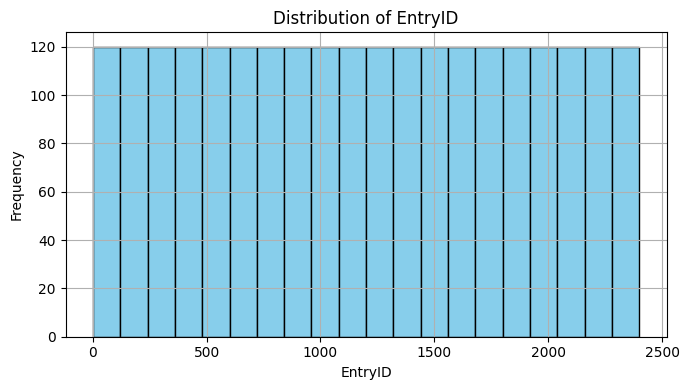

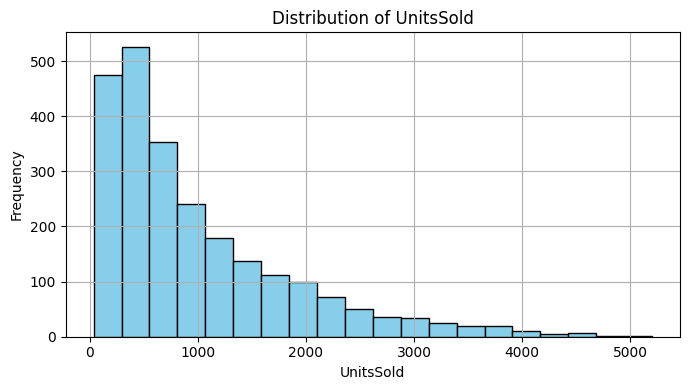

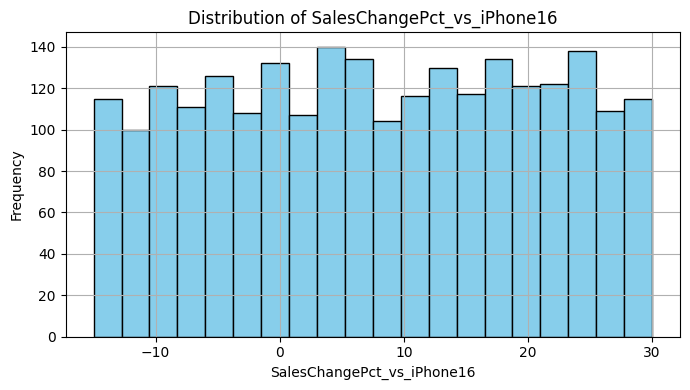

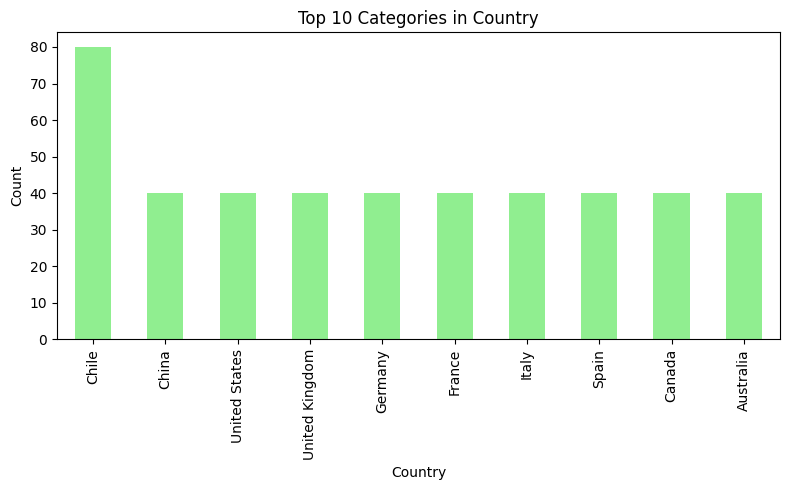

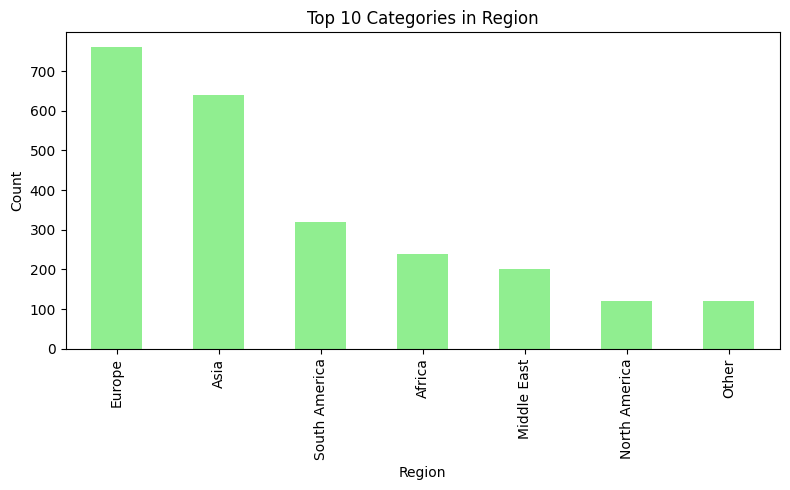

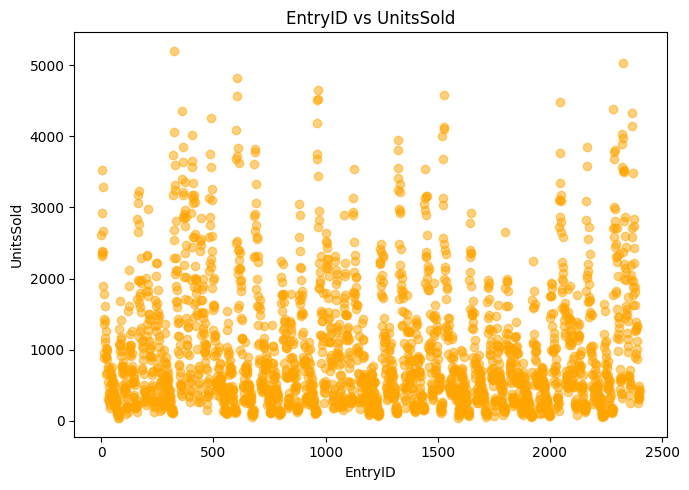

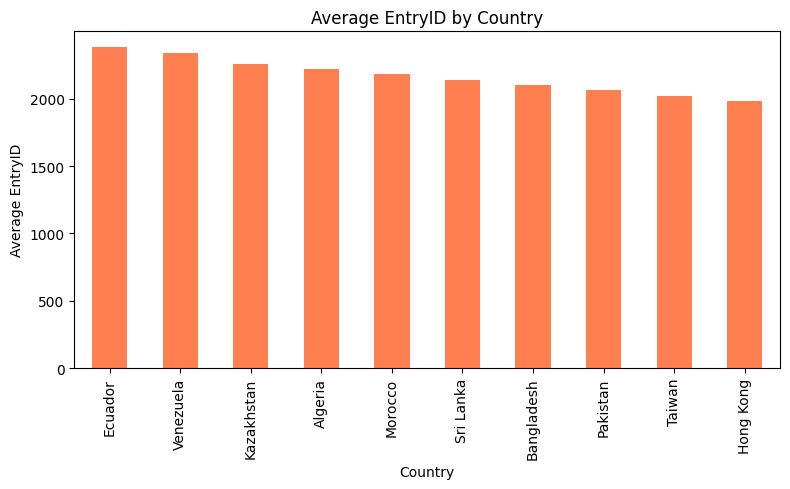

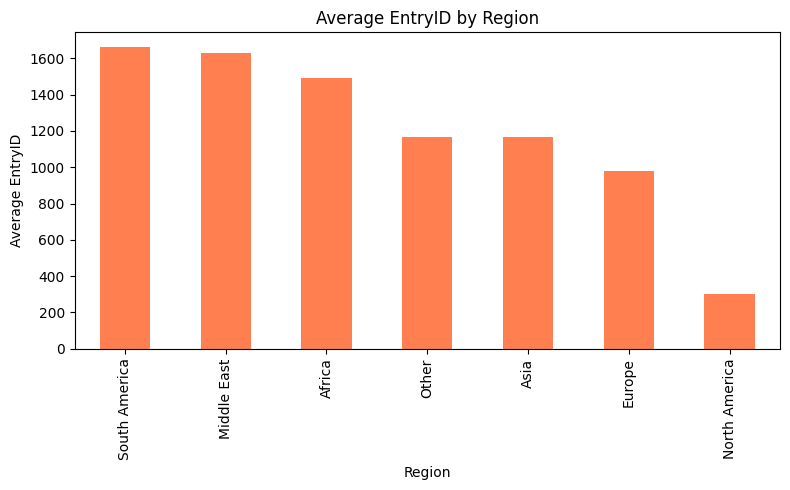


----- Correlation Matrix -----
                             EntryID  UnitsSold  SalesChangePct_vs_iPhone16  \
EntryID                     1.000000  -0.039096                    0.002730   
UnitsSold                  -0.039096   1.000000                    0.000757   
SalesChangePct_vs_iPhone16  0.002730   0.000757                    1.000000   
AvgPrice_USD                0.005647  -0.218517                    0.010714   
Revenue_USD                -0.039735   0.969532                   -0.001062   
ProfitEstimate_USD         -0.041177   0.910384                    0.000216   

                            AvgPrice_USD  Revenue_USD  ProfitEstimate_USD  
EntryID                         0.005647    -0.039735           -0.041177  
UnitsSold                      -0.218517     0.969532            0.910384  
SalesChangePct_vs_iPhone16      0.010714    -0.001062            0.000216  
AvgPrice_USD                    1.000000    -0.024900           -0.026094  
Revenue_USD                    -0.

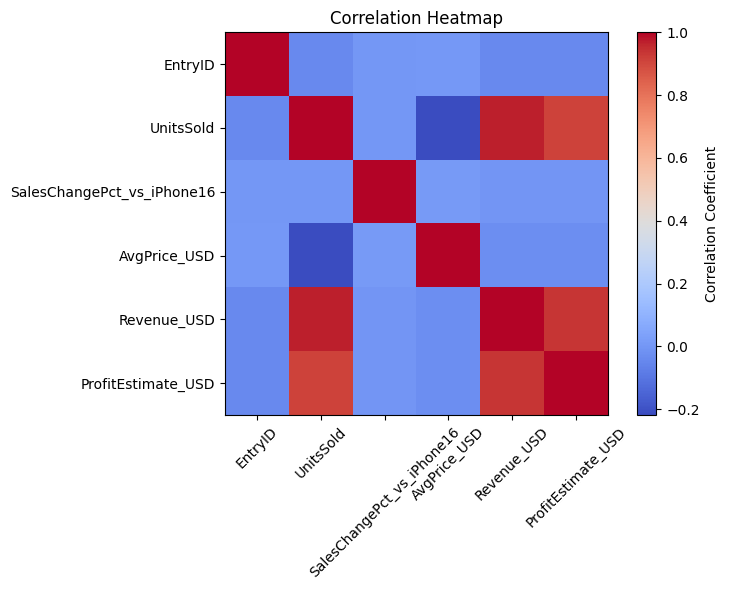

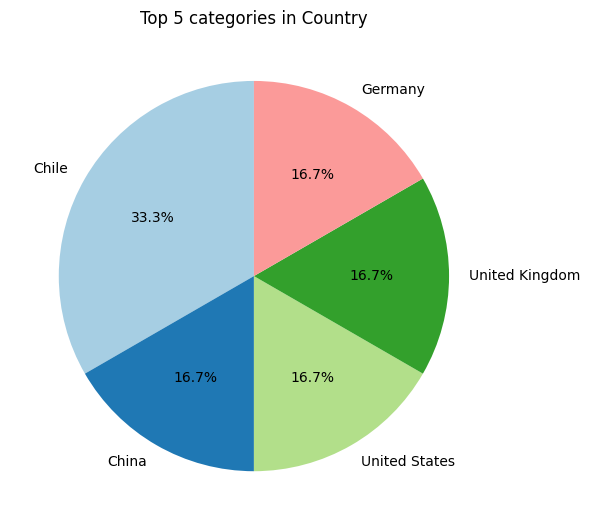


📈 QUICK INSIGHTS:
1. Dataset has 2400 rows and 14 columns.
2. Top columns analyzed: ['EntryID', 'UnitsSold', 'SalesChangePct_vs_iPhone16']
3. Top categorical columns: ['Country', 'Region', 'Model']
4. Missing values handled.
5. Several visualizations displayed for exploration.

✅ Analysis completed successfully!


In [2]:
# 📊 iPhone17 Dataset Analysis


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 1️⃣ Load Dataset
# =====================================================
file_path = "/content/iPhone17_2000rows_dataset.xlsx"
df = pd.read_excel(file_path)

print("✅ Dataset loaded successfully!")
print("--------------------------------------------------")
print("Rows:", df.shape[0], " | Columns:", df.shape[1])
print("\n----- First 5 Rows -----")
print(df.head())

# =====================================================
# 2️⃣ Basic Information and Cleaning
# =====================================================
print("\n----- Dataset Info -----")
print(df.info())

print("\n----- Missing Values -----")
print(df.isnull().sum())

# Drop completely empty columns (if any)
df = df.dropna(axis=1, how="all")

# Fill missing numeric values with the mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing text with "Unknown"
for col in df.select_dtypes(include="object").columns:
    df[col].fillna("Unknown", inplace=True)

print("\n✅ Missing values handled successfully!")

# =====================================================
# 3️⃣ Basic Statistics
# =====================================================
print("\n----- Basic Statistics for Numeric Columns -----")
print(df.describe())

# =====================================================
# 4️⃣ Univariate Analysis (Single-column insights)
# =====================================================

# Example 1: Histogram for a numeric column (price, rating, etc.)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(num_cols) > 0:
    for col in num_cols[:3]:  # limit to first 3 numeric columns
        plt.figure(figsize=(7,4))
        plt.hist(df[col], bins=20, color="skyblue", edgecolor="black")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Example 2: Bar chart for top categories (if categorical columns exist)
cat_cols = df.select_dtypes(include="object").columns.tolist()
if len(cat_cols) > 0:
    for col in cat_cols[:2]:
        plt.figure(figsize=(8,5))
        df[col].value_counts().head(10).plot(kind="bar", color="lightgreen")
        plt.title(f"Top 10 Categories in {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# =====================================================
# 5️⃣ Bivariate Analysis (Relationships between variables)
# =====================================================

# Example 1: Relationship between two numeric variables (scatter plot)
if len(num_cols) >= 2:
    plt.figure(figsize=(7,5))
    plt.scatter(df[num_cols[0]], df[num_cols[1]], alpha=0.5, color="orange")
    plt.title(f"{num_cols[0]} vs {num_cols[1]}")
    plt.xlabel(num_cols[0])
    plt.ylabel(num_cols[1])
    plt.tight_layout()
    plt.show()

# Example 2: Average numeric column per category (bar chart)
if len(cat_cols) > 0 and len(num_cols) > 0:
    for col in cat_cols[:2]:
        plt.figure(figsize=(8,5))
        avg_values = df.groupby(col)[num_cols[0]].mean().sort_values(ascending=False).head(10)
        avg_values.plot(kind="bar", color="coral")
        plt.title(f"Average {num_cols[0]} by {col}")
        plt.xlabel(col)
        plt.ylabel(f"Average {num_cols[0]}")
        plt.tight_layout()
        plt.show()

# =====================================================
# 6️⃣ Correlation Matrix (for numeric features)
# =====================================================
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    print("\n----- Correlation Matrix -----")
    print(corr)

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", interpolation="none")
    plt.colorbar(label="Correlation Coefficient")
    plt.xticks(range(len(num_cols)), num_cols, rotation=45)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# =====================================================
# 7️⃣ Additional Visuals (optional)
# =====================================================

# Pie chart for categorical feature
if len(cat_cols) > 0:
    plt.figure(figsize=(6,6))
    df[cat_cols[0]].value_counts().head(5).plot(
        kind="pie", autopct="%1.1f%%", startangle=90, colors=plt.cm.Paired.colors
    )
    plt.ylabel("")
    plt.title(f"Top 5 categories in {cat_cols[0]}")
    plt.tight_layout()
    plt.show()

# =====================================================
# 8️⃣ Key Insights Summary
# =====================================================
print("\n📈 QUICK INSIGHTS:")
print("1. Dataset has", df.shape[0], "rows and", df.shape[1], "columns.")
print("2. Top columns analyzed:", num_cols[:3])
print("3. Top categorical columns:", cat_cols[:3])
print("4. Missing values handled.")
print("5. Several visualizations displayed for exploration.")

print("\n✅ Analysis completed successfully!")

# =====================================================
# END OF SCRIPT
# =====================================================
